# _Anuario de Aforos_: selection of stations
***

***Author:** Chus Casado Rodríguez*<br>
***Date:** 05-05-2026*<br>

**Introducción:**<br>

This notebook analyses the data in the _Anuario de Aforos de España_ regarding gauging stations and streamflow.It does a pre-selection of stations to be included in CAMELS-ES based on:

* Minimum data availability in the streamflow series.
* Minimum catchment area

The selection is defined in the YAML configuration file.

**Outputs:**<br>
* A point GeoJSON file of the pre-selected stations.
* A CSV file required to delineate the basins of the pre-selected stations.

**To do**:<br>


In [1]:
import pandas as pd
import geopandas as gpd
from tqdm.notebook import tqdm
from pathlib import Path

from ocab.config import Config
from ocab.anuario.stations.stations import get_gauges_basin, get_gauges_miteco
from ocab.anuario.timeseries import get_river_series, manage_conflicts, select_study_period
from ocab.plots.stations import plot_stations_map
from ocab.basins.delineate.utils import create_input_file

## Configuration

In [2]:
cfg = Config('config_CAMELS_v200.yml')

# overlaping stations and action to take
conflicts = {
    (4207, 4208): 'remove 4208',
    (2095, 2530): 'combine',
    (1607, 1608): 'remove 1608',
    (7055, 7171, 7172): 'keep 7055'
}

# paths
path_aca = Path('/home/casadoj/Data/ACA/processed')
path_hidrosur = Path('/home/casadoj/Data/Hidrosur/processed')

## Gauging stations



### Anuario de Aforos

No. stations in   Cantabrico:	  95
No. stations in        Duero:	 210
No. stations in         Ebro:	 283
No. stations in Galicia costa:	  50
No. stations in Guadalquivir:	 116
No. stations in     Guadiana:	 145
No. stations in        Jucar:	 109
No. stations in     Miño-sil:	  86
No. stations in       Segura:	  82
No. stations in         Tajo:	 205
No. stations in     Cataluña:	  92
No. stations in    Andalucía:	  29

Total no. stations:		1502
Total no. active stations:	 987


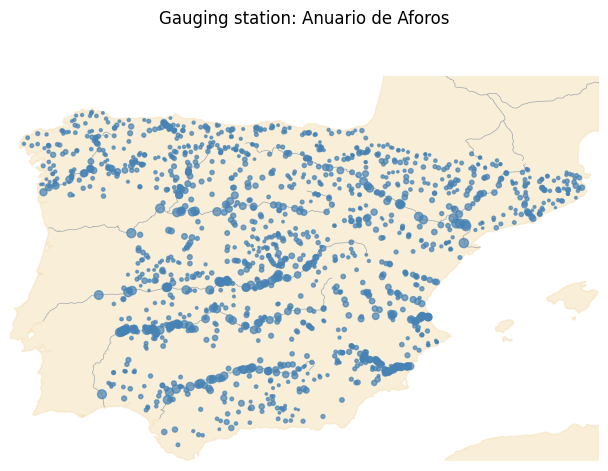

In [3]:
# identify basins
basins = {
    dir.stem: dir for dir in sorted(cfg.path_records.iterdir()) 
    if dir.is_dir() &  (dir.stem not in ['estaciones', 'GIS', 'timeseries'])
    }

# extract stations in Anuario de Aforos
stations = []
for basin, folder in basins.items():
    stns = get_gauges_basin(
        folder,
        min_area=cfg.area_min, 
        max_area=cfg.area_max, 
        years=cfg.min_years, 
        epsg=cfg.crs
        )
    stns['basin'] = basin
    stations.append(stns)
    print('No. stations in {0:>12}:\t{1:>4}'.format(basin.capitalize(), stns.shape[0]))
stations = pd.concat(stations, axis=0)
stations.sort_index(axis=0, inplace=True)

# add stations in Catalunya
stations_aca = gpd.read_file(path_aca / 'GIS' / 'stations_aca.geojson').set_index('id')
print('No. stations in {0:>12}:\t{1:>4}'.format('Cataluña', len(stations_aca)))
stations = pd.concat([stations, stations_aca], axis=0)
stations.sort_index(axis=0, inplace=True)

# add stations in Catalunya
stations_hidrosur = gpd.read_file(path_hidrosur / 'GIS' / 'gauges_hidrosur.geojson').set_index('id')
stations_hidrosur.drop(index=[6303, 6305], inplace=True) # already in "Anuario"!!
print('No. stations in {0:>12}:\t{1:>4}'.format('Andalucía', len(stations_hidrosur)))
stations = pd.concat([stations, stations_hidrosur], axis=0)
stations.sort_index(axis=0, inplace=True)

# mapa de las estaciones
plot_stations_map(
    stations.geometry, 
    area=stations.catch_skm, 
    extent=[-9.5, 3.5, 36, 44.5],
    title=f'Gauging station: Anuario de Aforos',
    # save=cfg.path_plots / 'stations.jpg'
)

print('\nTotal no. stations:\t\t{0:>4}'.format(stations.shape[0]))
print('Total no. active stations:\t{0:>4}'.format(stations.loc[stations.active == 1].shape[0]))

### MITECO

In [4]:
# load stations from MITECO
stations_miteco = get_gauges_miteco(
    cfg.path_records / 'estaciones' / 'Situac_4_Rio_rev.csv',
    # active=False,
    # min_area=cfg.area_min
)
print('No. stations in MITECO:\t\t{0:>4}'.format(stations_miteco.shape[0]))

missing_ids =stations.index.difference(stations_miteco.index)
print('No. stations missing in Miteco:\t{0:>4}'.format(len(missing_ids)))

# update missing values from those in MITECO
for col in stations.columns.intersection(stations_miteco.columns):
    stations[col] = stations[col].combine_first(stations_miteco[col])
    
# add new columns from MITECO
for col in stations_miteco.columns.difference(stations.columns):
    stations[col] = stations_miteco[col]

# sort columns
cols = sorted([col for col in stations.columns if col != 'geometry']) + ['geometry']
stations = stations[cols]

No. stations in MITECO:		1491
No. stations missing in Miteco:	 121


## Discharge Time Series

In [5]:
# extract time series from "Anuario de Aforos"
timeseries = {}
for basin, path in tqdm(basins.items(), desc='basins'):
    ids = stations[stations.basin == basin].index.to_list()
    data = get_river_series(
        path,
        ids, 
        start=cfg.start,
        end=cfg.end,
    )
    
    # check for conflicts
    data = manage_conflicts(data, conflicts)

    print('No. stations in {0:<14}\t\t{1:>4} ({2:>4})'.format(basin.title() + ':', len(data), len(ids)))
    timeseries.update(data)

# Cataluña
basin = 'CATALUÑA'
data = {}
ids = stations[stations.basin == basin].index.to_list()
for ID in ids:
    file = path_aca / 'timeseries' / 'stations' / '{0}.parquet'.format(stations.loc[ID, 'id_saih'])
    if file.is_file():
        ts = pd.read_parquet(file)
        ts = ts.loc[cfg.start:cfg.end].asfreq('D')
        if not ts.empty:
            data[ID] = ts
print('No. reservoirs in {0:<14}\t{1:>4} ({2:>4})'.format(basin.title()+ ':', len(data), len(ids)))
timeseries.update(data)

# Andalucía
basin = 'ANDALUCÍA'
data = {}
ids = stations[stations.basin == basin].index.to_list()
for ID in ids:
    file = path_hidrosur / 'timeseries' / 'stations' / '{0}.parquet'.format(stations.loc[ID, 'id_saih'])
    if file.is_file():
        ts = pd.read_parquet(file)
        if ts.index.tz is not None:
            ts.index = ts.index.tz_localize(None)
        ts = ts.loc[cfg.start:cfg.end].asfreq('D')
        if not ts.empty:
            data[ID] = ts
print('No. reservoirs in {0:<14}\t{1:>4} ({2:>4})'.format(basin.title()+ ':', len(data), len(ids)))
timeseries.update(data)

print('\nTotal no. sations with time series:\t{0:>4} ({1:>4})'.format(len(timeseries), len(stations)))

basins:   0%|          | 0/10 [00:00<?, ?it/s]

No. stations in Cantabrico:   		  81 (  95)
No. stations in Duero:        		 199 ( 210)
No. stations in Ebro:         		 262 ( 283)
No. stations in Galicia Costa:		  49 (  50)
No. stations in Guadalquivir: 		  97 ( 116)
No. stations in Guadiana:     		 109 ( 145)
No. stations in Jucar:        		  59 ( 109)
No. stations in Miño-Sil:     		  68 (  86)
No. stations in Segura:       		  52 (  82)
No. stations in Tajo:         		 180 ( 205)
No. reservoirs in Cataluña:     	  91 (  92)
No. reservoirs in Andalucía:    	  29 (  29)

Total no. sations with time series:	1276 (1502)


### Select Stations and Study Period

In [6]:
# add boolean fields with available variables
vars = ['discharge']
stations[vars ] = 0
for ID, ts in timeseries.items():
    stations.loc[ID, vars ] = [int(var in ts.columns) for var in vars]
mask_vars = stations[vars].any(axis=1)
print('No. stations with daily time series:\t\t\t{0:>4}'.format(mask_vars.sum()))

# pre-select best period of data
periods = pd.concat([
    select_study_period(
        ts[ts.columns.intersection(vars)], 
        ID,
        cfg.availability, 
        cfg.min_years, 
        mode='any'
    ) for ID, ts in timeseries.items()
], axis=0)
stations.loc[periods.index, ['start', 'end']] = periods.values

# compute no. years with daily time series
stations['years_daily'] = (stations.end - stations.start).astype('Int64')
mask_years = stations.years_daily >= cfg.min_years
print('No. stations with at least {0} years of daily data:\t{1:>4}'.format(cfg.min_years, mask_years.sum()))

# select stations
mask_stns = mask_years & mask_vars
print('No. selected stations:\t\t\t\t\t{0:>4}'.format(mask_stns.sum()))

No. stations with daily time series:			1252
No. stations with at least 4 years of daily data:	1312
No. selected stations:					1121


## Export



### Stations

In [7]:
# export shapefile
file_stations = cfg.path_gis / 'stations.geojson'
stations[mask_stns].to_file(file_stations, driver='GeoJSON')

#### `basin-delineation`

This section creates the GeoJSON file required as input to locate the stations in the MERIT and EFAS grids.

In [8]:
path = cfg.path_dataset / 'preprocessing' / 'basins'
path.mkdir(parents=True, exist_ok=True)
create_input_file(
    geometry=stations.loc[mask_stns, 'geometry'],
    area=stations.loc[mask_stns, 'catch_skm'],
    file=path / 'stations.geojson'
)

### Discharge time series

In [9]:
# exportar las series de caudal
path_ts = cfg.path_dataset / 'preprocessing' / 'timeseries' / 'discharge'
path_ts.mkdir(parents=True, exist_ok=True)
for ID in tqdm(stations[mask_stns].index, desc='stations'):
    ts = timeseries[ID][['discharge']]
    start, end = ts.first_valid_index(), ts.last_valid_index()
    # start, end = stations.loc[ID, ['inicio', 'fin']]
    ts.loc[start:end].to_parquet(path_ts / f'{ID}.parquet')

stations:   0%|          | 0/1121 [00:00<?, ?it/s]